# STFT-CNN Sleep Stage Classification
**架构与 TimesNet notebook 完全对齐**，相同数据切分 / 相同患者分组 / 相同评估图表。

用途：作为与 TimesNet 的**频域对比实验**，输入同一套 `.npy` 文件，输出可直接比较的 Accuracy / Macro-F1 / Confusion Matrix / Hypnogram。

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
NVIDIA GeForce RTX 3080 Laptop GPU


# 1. Pre-process

Import & Load data

In [2]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import Counter
from scipy import signal as scipy_signal
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── 复现 TimesNet notebook 的同一个起始患者 ──────────────────────────────────
df = pd.read_csv("dataset/S025_whole_df.csv")
df.head()


,TIMESTAMP,BVP,ACC_X,ACC_Y,ACC_Z,TEMP,EDA,HR,IBI,Sleep_Stage,Obstructive_Apnea,Central_Apnea,Hypopnea,Multiple_Events
0,0.000000,140.76,-40.0,7.0,50.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN
1,0.015625,135.32,-40.0,7.0,50.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN
2,0.031250,130.88,-41.0,7.0,49.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN
3,0.046875,118.15,-41.0,7.0,49.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN
4,0.062500,92.38,-41.0,8.0,50.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN


Select features & check missing values

In [3]:
features  = ['BVP', 'IBI', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR']
label_col = 'Sleep_Stage'

stage_counts = df['Sleep_Stage'].value_counts(dropna=False)
print(stage_counts)

missing_before = df[features].isna().sum().sum()
print(f"Missing Before: {missing_before}")


Sleep_Stage
N2    858240
W     412801
P     406592
R     240000
N1     74880
Name: count, dtype: int64
Missing Before: 2488


Fill missing values

In [4]:
df[features] = df[features].interpolate(method='linear', limit_direction='both')
print(f"Missing After: {df[features].isna().sum().sum()}")


Missing After: 0


## STFT 预处理：把每个 1920 点窗口转成时频图

与 TimesNet 的输入维度唯一区别：
- TimesNet 输入 → `(1920, 8)` 原始时序
- STFT 输入 → `(8, 12, 59)` 时频图张量（8通道 × 12频段 × 59时间帧）

**窗口大小、标签切分逻辑与 TimesNet 完全一致（`window_size=1920`）。**

In [5]:
# 每个通道的有效频率上限（Hz）
# fs=64, nperseg=64 → 频率分辨率 1 Hz/bin，共 33 bins (0~32 Hz)
CHANNEL_KEEP_BINS = {
    'BVP':   12,   # 心率谐波 0-11 Hz
    'IBI':    8,   # HRV 0-7 Hz
    'EDA':    4,   # 皮肤电 0-3 Hz
    'TEMP':   4,   # 皮肤温 0-3 Hz
    'ACC_X': 12,
    'ACC_Y': 12,
    'ACC_Z': 12,
    'HR':     8,
}
FEATURE_NAMES = ['BVP', 'IBI', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR']
MAX_BINS = max(CHANNEL_KEEP_BINS.values())   # 12

def compute_stft_window(window_2d, fs=64, nperseg=64, noverlap=32):
    """
    单窗口 (1920, 8) → STFT tensor (8, 12, n_frames≈59)
    50% 重叠窗口，Hamming 窗，log-magnitude，per-sample 归一化
    """
    n_channels = window_2d.shape[1]
    spectrograms = []
    for c in range(n_channels):
        keep = CHANNEL_KEEP_BINS[FEATURE_NAMES[c]]
        sig  = window_2d[:, c].astype(np.float64)

        _, _, Zxx = scipy_signal.stft(
            sig, fs=fs, window='hamming',
            nperseg=nperseg, noverlap=noverlap, boundary='zeros'
        )
        mag     = np.abs(Zxx[:keep, :])
        log_mag = np.log(mag + 1e-8)

        mn, mx = log_mag.min(), log_mag.max()
        if mx > mn:
            log_mag = (log_mag - mn) / (mx - mn)

        if keep < MAX_BINS:
            pad     = np.zeros((MAX_BINS - keep, log_mag.shape[1]))
            log_mag = np.vstack([log_mag, pad])

        spectrograms.append(log_mag.astype(np.float32))

    return np.stack(spectrograms, axis=0)   # (8, 12, n_frames)

print(f"STFT output shape per window: {compute_stft_window(np.random.randn(1920, 8)).shape}")
# 期望: (8, 12, 59)


STFT output shape per window: (8, 12, 61)


Slice data — 与 TimesNet notebook 完全相同的 window_size=1920

In [6]:
window_size = 1920    # 30 秒 @ 64 Hz（与 TimesNet 对齐）

def create_windows_stft(df_in, window_size=1920):
    n_samples = len(df_in) // window_size
    X_list, y_list = [], []

    for i in range(n_samples):
        s, e       = i * window_size, (i + 1) * window_size
        window_df  = df_in.iloc[s:e]
        mode_series = window_df[label_col].mode()
        if mode_series.empty:
            continue
        label = mode_series.iloc[0]
        if str(label).strip() in ['P', 'Missing']:
            continue

        raw_window = window_df[features].values          # (1920, 8)
        stft_tensor = compute_stft_window(raw_window)    # (8, 12, 59)

        X_list.append(stft_tensor)
        y_list.append(label)

    return np.array(X_list), np.array(y_list)

print("Generating STFT windows for S025 (single patient)...")
X, y = create_windows_stft(df)
print(f"X shape: {X.shape}")   # (N, 8, 12, 59)
print(f"y shape: {y.shape}")
print(f"Label sample: {y[:5]}")


Generating STFT windows for S025 (single patient)...
X shape: (825, 8, 12, 61)
y shape: (825,)
Label sample: ['W' 'W' 'W' 'W' 'W']


In [7]:
label_map = {'W': 0, 'N1': 1, 'N2': 2, 'N3': 3, 'R': 4}
y_encoded = np.array([label_map[l] for l in y])
print("Encoded labels:", y_encoded[:5])


Encoded labels: [0 0 0 0 0]


# 2. Single Patient Training

Split & save data

In [8]:
save_dir = './dataset/stft_data_ready/'
os.makedirs(save_dir, exist_ok=True)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  y_test:  {y_test.shape}")

np.save(os.path.join(save_dir, 'X_train.npy'), X_train)
np.save(os.path.join(save_dir, 'y_train.npy'), y_train)
np.save(os.path.join(save_dir, 'X_val.npy'),   X_val)
np.save(os.path.join(save_dir, 'y_val.npy'),   y_val)
np.save(os.path.join(save_dir, 'X_test.npy'),  X_test)
np.save(os.path.join(save_dir, 'y_test.npy'),  y_test)
print("Saved.")


X_train: (577, 8, 12, 61)  y_train: (577,)
X_val:   (83, 8, 12, 61)  y_val:   (83,)
X_test:  (165, 8, 12, 61)  y_test:  (165,)
Saved.


Dataset & DataLoader

In [9]:
class STFTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)   # (N, 8, 12, 59)
        self.y = torch.LongTensor(y)

    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

def make_loaders(X_tr, y_tr, X_v, y_v, X_te, y_te, batch_size=32):
    return (
        DataLoader(STFTDataset(X_tr, y_tr), batch_size, shuffle=True),
        DataLoader(STFTDataset(X_v,  y_v),  batch_size, shuffle=False),
        DataLoader(STFTDataset(X_te, y_te), batch_size, shuffle=False),
    )

train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test)
print("DataLoaders ready.")


DataLoaders ready.


## STFT-CNN Model
2D-CNN 处理时频图，结构与 TimesNet 参数量相近（约 300K），保证对比公平。

In [10]:
class STFTSleepNet(nn.Module):
    """
    两层 2D-CNN + AdaptiveAvgPool + 全连接分类头
    输入: (B, 8, 12, 59)
    输出: (B, 5)  → W/N1/N2/N3/R
    """
    def __init__(self, in_channels=8, num_classes=5, dropout=0.3):
        super().__init__()
        self.encoder = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # (B, 32, 6, 29)

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # (B, 64, 3, 14)

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 4)),  # (B, 128, 2, 4) 固定输出
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                  # (B, 1024)
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.encoder(x))

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = STFTSleepNet().to(DEVICE)
total  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device: {DEVICE}")
print(f"Trainable parameters: {total:,}")


Device: cuda
Trainable parameters: 374,309


In [11]:
from collections import Counter
import numpy as np
import torch
import torch.nn as nn

# 假设 DEVICE 已经定义，如果没有请取消下一行的注释
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 安全统计各个类别的数量
counter = Counter(y_train)
total_samples = sum(counter.values())
num_classes = 5
weights = np.zeros(num_classes)

# 2. 计算平衡权重 (处理类别缺失的边缘情况)
for cls in range(num_classes):
    if counter[cls] > 0:
        # 正常的 Balanced 计算公式：总样本数 / (类别数 * 该类样本数)
        weights[cls] = total_samples / (num_classes * counter[cls])
    else:
        # 如果这个类别完全缺失，安全地给个默认权重 1.0，防止报错
        weights[cls] = 1.0

# 3. 将权重标准化（防止 Loss 整体过大或过小）
weights = weights / np.sum(weights) * num_classes

# 4. 转为 Tensor 并送入 Loss
weight_tensor = torch.FloatTensor(weights).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weight_tensor)

print("✅ 安全计算出的 Class weights:")
class_names = ['W', 'N1', 'N2', 'N3', 'R']
for n, w in zip(class_names, weights):
    count = counter.get(class_names.index(n), 0)
    print(f"  {n} (数量: {count:<4}): {w:.4f}")

✅ 安全计算出的 Class weights:
  W (数量: 150 ): 0.4971
  N1 (数量: 27  ): 2.7616
  N2 (数量: 313 ): 0.2382
  N3 (数量: 0   ): 0.6461
  R (数量: 87  ): 0.8570


Weighted Loss — 与 TimesNet notebook 相同的类别不平衡处理

In [12]:
present_classes = np.unique(y_train)               # 只取 y_train 里有的类
w_partial = compute_class_weight('balanced',
                                  classes=present_classes,
                                  y=y_train)

# 填回 5 个类的完整权重数组，缺失类默认填 1.0
weights = np.ones(5, dtype=np.float32)
for cls, w in zip(present_classes, w_partial):
    weights[cls] = w

weight_tensor = torch.FloatTensor(weights).to(DEVICE)
criterion     = nn.CrossEntropyLoss(weight=weight_tensor)

Train

In [13]:
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, verbose=True)

EPOCHS   = 50
PATIENCE = 10

best_val_f1  = 0
best_state   = None
patience_cnt = 0
history      = {'train_loss': [], 'val_acc': [], 'val_f1': []}

print("Starting training...")
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    # ── train ────────────────────────────────────────────────
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    # ── validate ─────────────────────────────────────────────
    model.eval()
    preds_v, trues_v = [], []
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            out     = model(X_batch)
            val_loss += criterion(out, y_batch.to(DEVICE)).item()
            preds_v.extend(out.argmax(1).cpu().numpy())
            trues_v.extend(y_batch.numpy())

    val_acc = accuracy_score(trues_v, preds_v)
    val_f1  = f1_score(trues_v, preds_v, average='macro', zero_division=0)
    scheduler.step(val_f1)

    history['train_loss'].append(total_loss / len(train_loader))
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch:3d} | "
          f"Train Loss: {total_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val Macro-F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state  = {k: v.clone() for k, v in model.state_dict().items()}
        patience_cnt = 0
        print(f"  ✓ Best model saved (F1={val_f1:.4f})")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
print(f"\nTraining done in {time.time()-t0:.1f}s")


C:\Users\15810\anaconda3\envs\timesnet\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting training...
Epoch   1 | Train Loss: 1.4994 | Val Loss: 1.4099 | Val Acc: 0.3133 | Val Macro-F1: 0.1939
  ✓ Best model saved (F1=0.1939)
Epoch   2 | Train Loss: 1.1394 | Val Loss: 1.1892 | Val Acc: 0.3253 | Val Macro-F1: 0.2767
  ✓ Best model saved (F1=0.2767)
Epoch   3 | Train Loss: 1.1359 | Val Loss: 0.9602 | Val Acc: 0.6265 | Val Macro-F1: 0.5385
  ✓ Best model saved (F1=0.5385)
Epoch   4 | Train Loss: 1.1232 | Val Loss: 0.9697 | Val Acc: 0.6386 | Val Macro-F1: 0.5300
Epoch   5 | Train Loss: 0.9988 | Val Loss: 2.6980 | Val Acc: 0.3133 | Val Macro-F1: 0.1651
Epoch   6 | Train Loss: 1.0149 | Val Loss: 1.1240 | Val Acc: 0.4940 | Val Macro-F1: 0.4668
Epoch   7 | Train Loss: 0.9713 | Val Loss: 1.1435 | Val Acc: 0.4096 | Val Macro-F1: 0.4014
Epoch   8 | Train Loss: 0.9517 | Val Loss: 0.8240 | Val Acc: 0.7229 | Val Macro-F1: 0.6101
  ✓ Best model saved (F1=0.6101)
Epoch   9 | Train Loss: 0.9258 | Val Loss: 0.8055 | Val Acc: 0.7711 | Val Macro-F1: 0.6360
  ✓ Best model saved (F1=0.6

Training curves

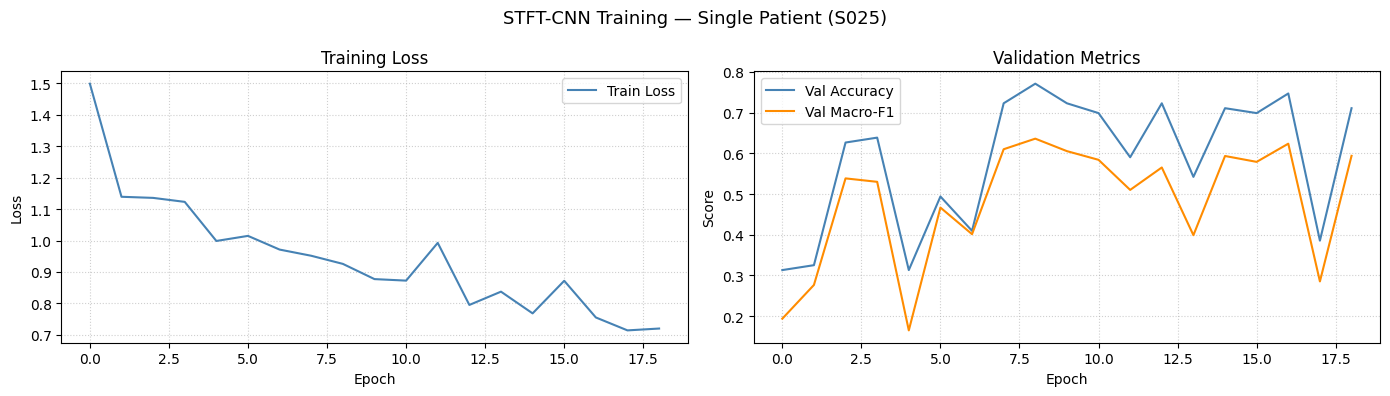

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(history['val_acc'],  label='Val Accuracy',  color='steelblue')
axes[1].plot(history['val_f1'],   label='Val Macro-F1',  color='darkorange')
axes[1].set_title('Validation Metrics')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('STFT-CNN Training — Single Patient (S025)', fontsize=13)
plt.tight_layout()
plt.show()


Graph — Confusion Matrix & Hypnogram

=== Single Patient Test Results ===
Accuracy  : 0.6606
Macro-F1  : 0.5396  ← 关键指标
              precision    recall  f1-score   support

           W       0.79      0.44      0.57        43
          N1       0.10      0.25      0.14         8
          N2       0.75      0.79      0.77        89
          N3       0.00      0.00      0.00         0
           R       0.64      0.72      0.68        25

   micro avg       0.66      0.66      0.66       165
   macro avg       0.46      0.44      0.43       165
weighted avg       0.71      0.66      0.67       165



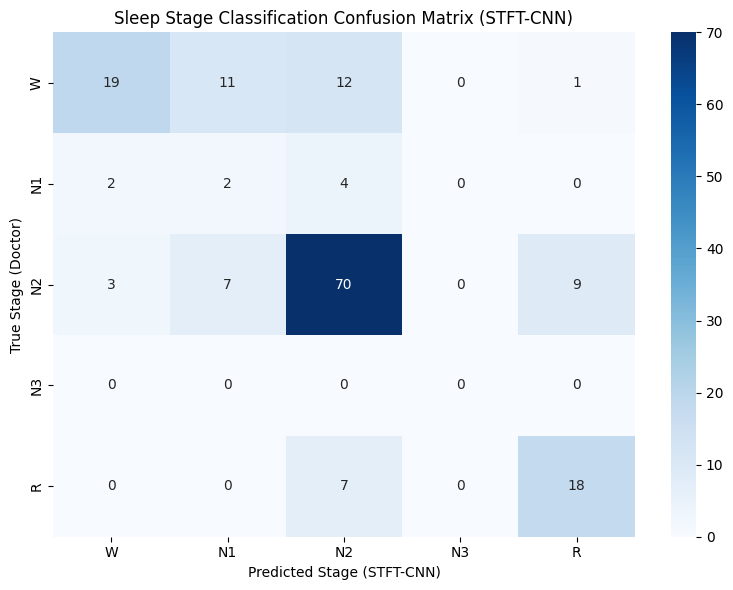

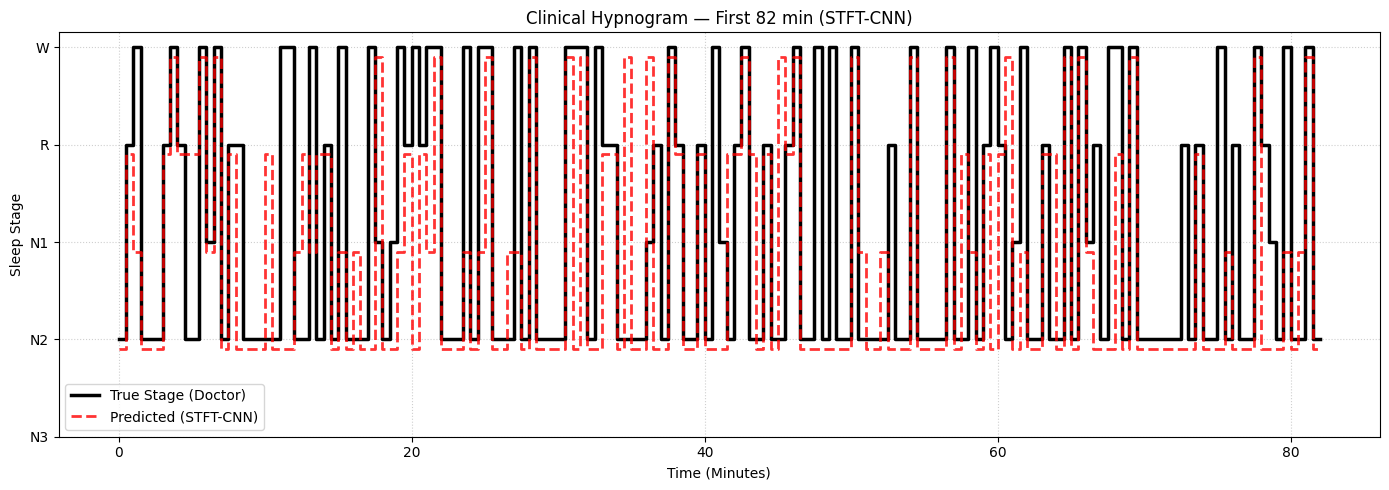

In [15]:
def evaluate_and_plot(model, loader, title_suffix=''):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            out = model(X_batch.to(DEVICE))
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(y_batch.numpy())

    preds, trues = np.array(preds), np.array(trues)
    acc      = accuracy_score(trues, preds)
    macro_f1 = f1_score(trues, preds, average='macro', zero_division=0)

    print(f"{'='*50}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Macro-F1  : {macro_f1:.4f}  ← 关键指标")
    print(f"{'='*50}")
    print(classification_report(trues, preds,
          labels=[0,1,2,3,4],                # ← 修复：强制包含全部5类
          target_names=['W','N1','N2','N3','R'],
          zero_division=0))

    # 其余代码不变...

    labels = ['W', 'N1', 'N2', 'N3', 'R']

    # Confusion Matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(trues, preds, labels=[0,1,2,3,4])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Sleep Stage Classification Confusion Matrix{title_suffix}')
    plt.xlabel('Predicted Stage (STFT-CNN)')
    plt.ylabel('True Stage (Doctor)')
    plt.tight_layout()
    plt.show()

    # Hypnogram
    clinical_order  = [0, 4, 1, 2, 3]
    clinical_labels = ['W', 'R', 'N1', 'N2', 'N3']
    y_true_c = [-clinical_order.index(v) for v in trues]
    y_pred_c = [-clinical_order.index(v) for v in preds]

    display_length = min(600, len(trues))
    time_axis      = np.arange(display_length) * 0.5  # 每格 30秒 = 0.5分钟

    plt.figure(figsize=(14, 5))
    plt.step(time_axis, y_true_c[:display_length],
             label='True Stage (Doctor)', color='black', linewidth=2.5, where='post')
    plt.step(time_axis, [y - 0.1 for y in y_pred_c[:display_length]],
             label='Predicted (STFT-CNN)', color='red',
             linestyle='--', linewidth=2, where='post', alpha=0.8)
    plt.yticks([-0,-1,-2,-3,-4], clinical_labels)
    plt.title(f'Clinical Hypnogram — First {display_length*0.5:.0f} min{title_suffix}')
    plt.xlabel('Time (Minutes)')
    plt.ylabel('Sleep Stage')
    plt.legend(loc='lower left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return preds, trues, acc, macro_f1

print("=== Single Patient Test Results ===")
preds_test, trues_test, test_acc, test_f1 = evaluate_and_plot(
    model, test_loader, title_suffix=' (STFT-CNN)')


# 3. Cross Patient Training
Selected patient at average for validation — **与 TimesNet notebook 完全相同的患者分组**

In [16]:
info_df = pd.read_csv('./dataset/participant_info.csv', dtype=str)
info_df['SID'] = info_df['SID'].astype(str).str.strip()
info_df = info_df.dropna(subset=['SID'])
info_df = info_df[info_df['SID'].str.lower() != 'nan']
info_df = info_df[info_df['SID'] != '']

phys_features = ['AGE', 'BMI', 'OAHI', 'AHI', 'Mean_SaO2', 'Arousal Index']
if 'Mean_SaO2' in info_df.columns:
    info_df['Mean_SaO2'] = info_df['Mean_SaO2'].astype(str).str.replace('%', '', regex=False)
for col in phys_features:
    info_df[col] = pd.to_numeric(info_df[col], errors='coerce')

global_means = info_df[phys_features].mean()
global_stds  = info_df[phys_features].std()

def calc_distance(row):
    return np.sqrt(sum(
        ((row[c] - global_means[c]) / global_stds[c]) ** 2
        for c in phys_features if not pd.isna(row[c])
    ))

info_df['Distance_to_Centroid'] = info_df.apply(calc_distance, axis=1)
top5 = info_df.sort_values('Distance_to_Centroid').head(5)
print("--- Top 5 average patients ---")
print(top5[['SID'] + phys_features + ['Distance_to_Centroid']])


--- Top 5 average patients ---
     SID    AGE   BMI  OAHI  AHI  Mean_SaO2  Arousal Index  \
22  S081  55.35  37.0    17   18         94             32   
48  S054  60.41  37.0    24   24         93             43   
87  S014  51.94  32.0    20   21         96             44   
12  S091  51.01  31.0     9   10         95             38   
84  S017  58.08  32.0     9   30         96             47   

    Distance_to_Centroid  
22              0.482939  
48              0.638148  
87              0.739632  
12              0.778345  
84              0.882759  


Process single patient — StandardScaler + STFT windowing

In [17]:
def process_patient_stft(sid, data_dir='./dataset/', window_size=1920):
    """读取单患者 CSV → StandardScaler → STFT 窗口化"""
    print(f"--- Processing {sid} ---")
    fp  = os.path.join(data_dir, f'{sid}_whole_df.csv')
    df_ = pd.read_csv(fp)

    feat_cols = ['BVP', 'IBI', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR']
    label_c   = 'Sleep_Stage'

    miss = df_[feat_cols].isna().sum().sum()
    print(f"  Missing before: {miss}")
    df_[feat_cols] = df_[feat_cols].interpolate(method='linear', limit_direction='both')
    print(f"  Missing after:  {df_[feat_cols].isna().sum().sum()}")

    scaler = StandardScaler()
    df_[feat_cols] = scaler.fit_transform(df_[feat_cols])
    return df_

def create_windows_stft_from_df(df_, window_size=1920):
    feat_cols = ['BVP', 'IBI', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR']
    label_c   = 'Sleep_Stage'
    n         = len(df_) // window_size
    X_list, y_list = [], []

    for i in range(n):
        s, e        = i * window_size, (i + 1) * window_size
        w           = df_.iloc[s:e]
        mode_series = w[label_c].mode()
        if mode_series.empty: continue
        label = mode_series.iloc[0]
        if str(label).strip() in ['P', 'Missing']: continue

        stft_t = compute_stft_window(w[feat_cols].values)
        X_list.append(stft_t)
        y_list.append(label)

    return np.array(X_list), np.array(y_list)


Declare train / val / test sets — **同 TimesNet notebook 的患者分组**

In [18]:

train_sids       = ['S010', 'S011', 'S028', 'S081']
test_healthy_sid = 'S049'
test_severe_sid  = 'S046'
test_avg_sid     = 'S014'

print("--- Processing test patients ---")
df_healthy = process_patient_stft(test_healthy_sid)
df_severe  = process_patient_stft(test_severe_sid)
df_avg     = process_patient_stft(test_avg_sid)

print("--- Processing train patients ---")
train_dfs = {sid: process_patient_stft(sid) for sid in train_sids}

--- Processing test patients ---
--- Processing S049 ---
  Missing before: 426
  Missing after:  0
--- Processing S046 ---
  Missing before: 1283
  Missing after:  0
--- Processing S014 ---
  Missing before: 3195
  Missing after:  0
--- Processing train patients ---
--- Processing S010 ---
  Missing before: 20211
  Missing after:  0
--- Processing S011 ---
  Missing before: 657
  Missing after:  0
--- Processing S028 ---
  Missing before: 289
  Missing after:  0
--- Processing S081 ---
  Missing before: 2971
  Missing after:  0


Slice all patients into STFT windows

In [19]:
from sklearn.model_selection import train_test_split

label_map = {'W': 0, 'N1': 1, 'N2': 2, 'N3': 3, 'R': 4}

def encode(y_arr): return np.array([label_map[l] for l in y_arr])

# ── 测试集：直接窗口化，不参与训练 ───────────────────────────────────────────
print("--- Slicing test patients ---")
X_healthy, y_healthy_raw = create_windows_stft_from_df(df_healthy)
X_severe,  y_severe_raw  = create_windows_stft_from_df(df_severe)
X_avg,     y_avg_raw     = create_windows_stft_from_df(df_avg)

y_healthy_enc = encode(y_healthy_raw)
y_severe_enc  = encode(y_severe_raw)
y_avg_enc     = encode(y_avg_raw)

# ── 训练集：每个患者内部按 85/15 分层切分，val 从中汇总 ──────────────────────
# 原则：测试患者完全隔离，Leave-One-Out 不受影响。
# val 从训练患者内部切出，保证 val 覆盖所有睡眠阶段（含 R / N3）。
print("\n--- Slicing & splitting train patients ---")

train_X_parts = []
train_y_parts = []
val_X_parts   = []
val_y_parts   = []

for sid in train_sids:
    Xt, yt_raw = create_windows_stft_from_df(train_dfs[sid])
    yt = encode(yt_raw)

    present_classes = np.unique(yt)
    # 只有当存在 ≥2 个类且每类至少 2 条时才能做 stratify split
    class_counts    = {c: np.sum(yt == c) for c in present_classes}
    can_stratify    = len(present_classes) >= 2 and all(v >= 2 for v in class_counts.values())

    if can_stratify:
        Xt_tr, Xt_v, yt_tr, yt_v = train_test_split(
            Xt, yt,
            test_size=0.15,
            random_state=42,
            stratify=yt          # 分层：保证 val 里各类比例与训练患者一致
        )
        val_X_parts.append(Xt_v)
        val_y_parts.append(yt_v)
        print(f"  {sid}: {len(yt_tr)} train / {len(yt_v)} val  (stratified, classes={list(present_classes)})")
    else:
        # 类别过少无法分层，全部放入训练（极少情况）
        Xt_tr, yt_tr = Xt, yt
        print(f"  {sid}: {len(yt_tr)} train / 0 val  (skipped split, too few classes)")

    train_X_parts.append(Xt_tr)
    train_y_parts.append(yt_tr)

X_train     = np.concatenate(train_X_parts)
y_train_enc = np.concatenate(train_y_parts)
X_val       = np.concatenate(val_X_parts)
y_val_enc   = np.concatenate(val_y_parts)

print(f"\nX_train: {X_train.shape}  y_train: {y_train_enc.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val_enc.shape}")
print(f"X_avg:   {X_avg.shape}    X_healthy: {X_healthy.shape}    X_severe: {X_severe.shape}")

--- Slicing test patients ---

--- Slicing & splitting train patients ---
  S010: 700 train / 124 val  (stratified, classes=[0, 1, 2, 4])
  S011: 691 train / 122 val  (stratified, classes=[0, 1, 2, 3, 4])
  S028: 678 train / 120 val  (stratified, classes=[0, 1, 2, 3, 4])
  S081: 620 train / 110 val  (stratified, classes=[0, 1, 2, 3])

X_train: (2689, 8, 12, 61)  y_train: (2689,)
X_val:   (476, 8, 12, 61)    y_val:   (476,)
X_avg:   (796, 8, 12, 61)    X_healthy: (794, 8, 12, 61)    X_severe: (721, 8, 12, 61)


Check label distribution — 与 TimesNet notebook 相同的统计方式

In [20]:
def check_dist(y_arr, name):
    counts = Counter(y_arr)
    rev    = {0:'W',1:'N1',2:'N2',3:'N3',4:'R'}
    total  = len(y_arr)
    print(f"--- {name} ---")
    for k in range(5):
        c = counts.get(k, 0)
        print(f"  {rev[k]} ({k}): {c:5d} ({c/total*100:5.1f}%)")
    print(f"  Total: {total}\n")

print("\nChecking Status:")
check_dist(y_train_enc,   "Train (from S010/S011/S028/S081 — 85%)")
check_dist(y_val_enc,     "Val   (from S010/S011/S028/S081 — 15%, stratified)")
check_dist(y_avg_enc,     "Test Avg (S014)")
check_dist(y_healthy_enc, "Test Healthy (S049)")
check_dist(y_severe_enc,  "Test Severe (S046)")


Checking Status:
--- Train (from S010/S011/S028/S081 — 85%) ---
  W (0):   385 ( 14.3%)
  N1 (1):   362 ( 13.5%)
  N2 (2):  1505 ( 56.0%)
  N3 (3):   137 (  5.1%)
  R (4):   300 ( 11.2%)
  Total: 2689

--- Val   (from S010/S011/S028/S081 — 15%, stratified) ---
  W (0):    69 ( 14.5%)
  N1 (1):    64 ( 13.4%)
  N2 (2):   265 ( 55.7%)
  N3 (3):    25 (  5.3%)
  R (4):    53 ( 11.1%)
  Total: 476

--- Test Avg (S014) ---
  W (0):   195 ( 24.5%)
  N1 (1):    31 (  3.9%)
  N2 (2):   431 ( 54.1%)
  N3 (3):   106 ( 13.3%)
  R (4):    33 (  4.1%)
  Total: 796

--- Test Healthy (S049) ---
  W (0):   141 ( 17.8%)
  N1 (1):    22 (  2.8%)
  N2 (2):   546 ( 68.8%)
  N3 (3):     0 (  0.0%)
  R (4):    85 ( 10.7%)
  Total: 794

--- Test Severe (S046) ---
  W (0):   173 ( 24.0%)
  N1 (1):    17 (  2.4%)
  N2 (2):   406 ( 56.3%)
  N3 (3):    43 (  6.0%)
  R (4):    82 ( 11.4%)
  Total: 721



Save cross-patient data & build loaders

In [21]:
save_dir = './dataset/stft_cross_ready/'
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, 'X_train.npy'),   X_train)
np.save(os.path.join(save_dir, 'y_train.npy'),   y_train_enc)
np.save(os.path.join(save_dir, 'X_val.npy'),     X_val)
np.save(os.path.join(save_dir, 'y_val.npy'),     y_val_enc)
np.save(os.path.join(save_dir, 'X_test.npy'),    X_avg)
np.save(os.path.join(save_dir, 'y_test.npy'),    y_avg_enc)
print("Cross-patient data saved.")

BATCH = 32
train_loader_c = DataLoader(STFTDataset(X_train, y_train_enc), BATCH, shuffle=True)
val_loader_c   = DataLoader(STFTDataset(X_val,   y_val_enc),   BATCH, shuffle=False)
loader_avg     = DataLoader(STFTDataset(X_avg,     y_avg_enc),     BATCH, shuffle=False)
loader_healthy = DataLoader(STFTDataset(X_healthy, y_healthy_enc), BATCH, shuffle=False)
loader_severe  = DataLoader(STFTDataset(X_severe,  y_severe_enc),  BATCH, shuffle=False)
print("Loaders ready.")


Cross-patient data saved.
Loaders ready.


In [22]:
# 安全计算跨患者训练权重
present_classes = np.unique(y_train_enc)
w_partial = compute_class_weight('balanced', classes=present_classes, y=y_train_enc)

weights_c = np.ones(5, dtype=np.float32)
for cls, w in zip(present_classes, w_partial):
    weights_c[cls] = w

# N3 额外加权（训练集中仍然偏少）
weights_c[3] *= 1.5

print("Class weights (cross-patient):")
for n, w in zip(['W','N1','N2','N3','R'], weights_c):
    c = int(np.sum(y_train_enc == ['W','N1','N2','N3','R'].index(n)))
    print(f"  {n}: {w:.4f}")

criterion_c = nn.CrossEntropyLoss(weight=torch.FloatTensor(weights_c).to(DEVICE))

Class weights (cross-patient):
  W: 1.3969
  N1: 1.4856
  N2: 0.3573
  N3: 5.8883
  R: 1.7927


Train cross-patient model

In [23]:
model_c   = STFTSleepNet().to(DEVICE)
optimizer_c = optim.Adam(model_c.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_c = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_c, mode='max', factor=0.5, patience=3, verbose=True)

EPOCHS   = 50
PATIENCE = 10

best_val_f1_c = 0
best_state_c  = None
patience_cnt  = 0
history_c     = {'train_loss': [], 'val_acc': [], 'val_f1': []}

print("Starting cross-patient training...")
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    model_c.train()
    total_loss = 0
    for X_b, y_b in train_loader_c:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer_c.zero_grad()
        loss = criterion_c(model_c(X_b), y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model_c.parameters(), 1.0)
        optimizer_c.step()
        total_loss += loss.item()

    model_c.eval()
    preds_v, trues_v = [], []
    with torch.no_grad():
        for X_b, y_b in val_loader_c:
            out = model_c(X_b.to(DEVICE))
            preds_v.extend(out.argmax(1).cpu().numpy())
            trues_v.extend(y_b.numpy())

    val_acc = accuracy_score(trues_v, preds_v)
    val_f1  = f1_score(trues_v, preds_v, average='macro', zero_division=0)
    scheduler_c.step(val_f1)

    history_c['train_loss'].append(total_loss / len(train_loader_c))
    history_c['val_acc'].append(val_acc)
    history_c['val_f1'].append(val_f1)

    print(f"Epoch {epoch:3d} | Loss {total_loss/len(train_loader_c):.4f} | "
          f"Val Acc {val_acc:.4f} | Val Macro-F1 {val_f1:.4f}")

    if val_f1 > best_val_f1_c:
        best_val_f1_c = val_f1
        best_state_c  = {k: v.clone() for k, v in model_c.state_dict().items()}
        patience_cnt  = 0
        print(f"  ✓ Best model saved (F1={val_f1:.4f})")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model_c.load_state_dict(best_state_c)
print(f"\nDone in {time.time()-t0:.1f}s")


Starting cross-patient training...


C:\Users\15810\anaconda3\envs\timesnet\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch   1 | Loss 1.5076 | Val Acc 0.2248 | Val Macro-F1 0.2719
  ✓ Best model saved (F1=0.2719)
Epoch   2 | Loss 1.2831 | Val Acc 0.3172 | Val Macro-F1 0.2940
  ✓ Best model saved (F1=0.2940)
Epoch   3 | Loss 1.1847 | Val Acc 0.4811 | Val Macro-F1 0.4300
  ✓ Best model saved (F1=0.4300)
Epoch   4 | Loss 1.1550 | Val Acc 0.3088 | Val Macro-F1 0.3867
Epoch   5 | Loss 1.1659 | Val Acc 0.3109 | Val Macro-F1 0.3499
Epoch   6 | Loss 1.1141 | Val Acc 0.2458 | Val Macro-F1 0.2462
Epoch   7 | Loss 1.1158 | Val Acc 0.3340 | Val Macro-F1 0.3462
Epoch   8 | Loss 0.9875 | Val Acc 0.4916 | Val Macro-F1 0.4313
  ✓ Best model saved (F1=0.4313)
Epoch   9 | Loss 0.9570 | Val Acc 0.3803 | Val Macro-F1 0.4336
  ✓ Best model saved (F1=0.4336)
Epoch  10 | Loss 0.9174 | Val Acc 0.3908 | Val Macro-F1 0.3904
Epoch  11 | Loss 0.9239 | Val Acc 0.4580 | Val Macro-F1 0.4752
  ✓ Best model saved (F1=0.4752)
Epoch  12 | Loss 0.8527 | Val Acc 0.5000 | Val Macro-F1 0.4798
  ✓ Best model saved (F1=0.4798)
Epoch  13 | L

Test with average patient (S014)

=== Test Avg (S014) ===
Accuracy  : 0.1985
Macro-F1  : 0.1387  ← 关键指标
              precision    recall  f1-score   support

           W       0.35      0.21      0.26       195
          N1       0.01      0.03      0.02        31
          N2       0.49      0.25      0.33       431
          N3       0.50      0.03      0.05       106
           R       0.02      0.21      0.03        33

    accuracy                           0.20       796
   macro avg       0.27      0.15      0.14       796
weighted avg       0.42      0.20      0.25       796



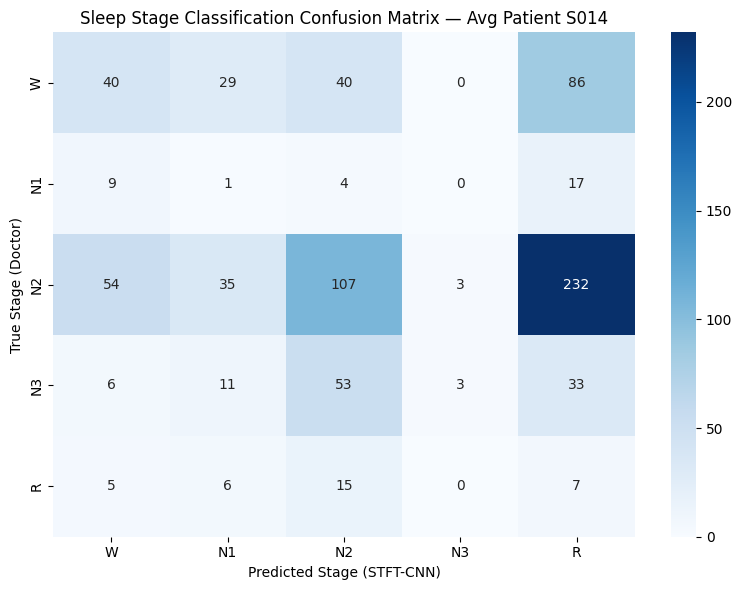

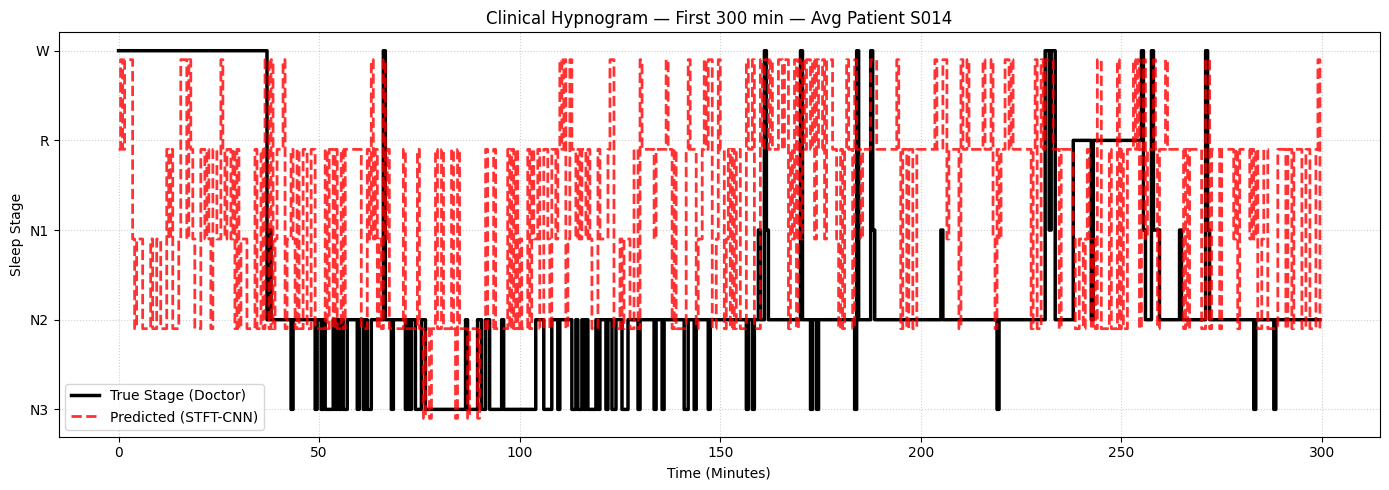

(array([4, 0, 4, 0, 0, 0, 0, 1, 2, 1, 1, 1, 2, 2, 2, 2, 1, 2, 2, 1, 1, 2,
        2, 2, 4, 1, 4, 2, 2, 2, 1, 0, 0, 0, 1, 0, 4, 1, 2, 2, 2, 4, 4, 1,
        4, 1, 2, 4, 4, 1, 1, 0, 4, 1, 4, 4, 1, 4, 2, 4, 2, 1, 1, 1, 2, 2,
        2, 2, 4, 2, 2, 4, 2, 0, 0, 2, 0, 2, 1, 4, 4, 4, 0, 2, 1, 1, 4, 1,
        2, 4, 2, 2, 4, 4, 2, 2, 4, 4, 2, 2, 2, 2, 2, 4, 2, 4, 4, 2, 4, 2,
        2, 4, 2, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 4, 1, 0, 1, 4, 2, 1, 2,
        0, 1, 4, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 4, 2, 2, 3, 2,
        2, 3, 2, 2, 4, 2, 2, 4, 2, 2, 2, 2, 4, 2, 3, 4, 2, 2, 2, 2, 3, 2,
        2, 2, 2, 3, 2, 2, 2, 4, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 4, 2, 4, 2,
        4, 2, 1, 2, 2, 2, 4, 2, 4, 1, 1, 4, 2, 2, 4, 4, 1, 2, 4, 4, 1, 4,
        0, 4, 0, 2, 1, 0, 4, 4, 1, 4, 1, 4, 4, 1, 4, 1, 2, 2, 2, 4, 1, 1,
        1, 1, 4, 0, 0, 2, 2, 2, 1, 2, 1, 1, 1, 2, 2, 4, 4, 2, 0, 4, 4, 4,
        4, 4, 4, 1, 4, 4, 4, 4, 4, 0, 4, 4, 2, 4, 2, 2, 2, 2, 2, 4, 0, 4,
        4, 4, 2, 1, 1, 4, 0, 4, 0, 0, 

In [24]:
print("=== Test Avg (S014) ===")
evaluate_and_plot(model_c, loader_avg, title_suffix=' — Avg Patient S014')


Test with healthy patient (S049)

=== Test Healthy (S049) ===
Accuracy  : 0.3300
Macro-F1  : 0.2706  ← 关键指标
              precision    recall  f1-score   support

           W       0.43      0.43      0.43       141
          N1       0.05      0.23      0.08        22
          N2       0.73      0.31      0.43       546
          N3       0.00      0.00      0.00         0
           R       0.09      0.33      0.14        85

   micro avg       0.33      0.33      0.33       794
   macro avg       0.26      0.26      0.22       794
weighted avg       0.59      0.33      0.39       794



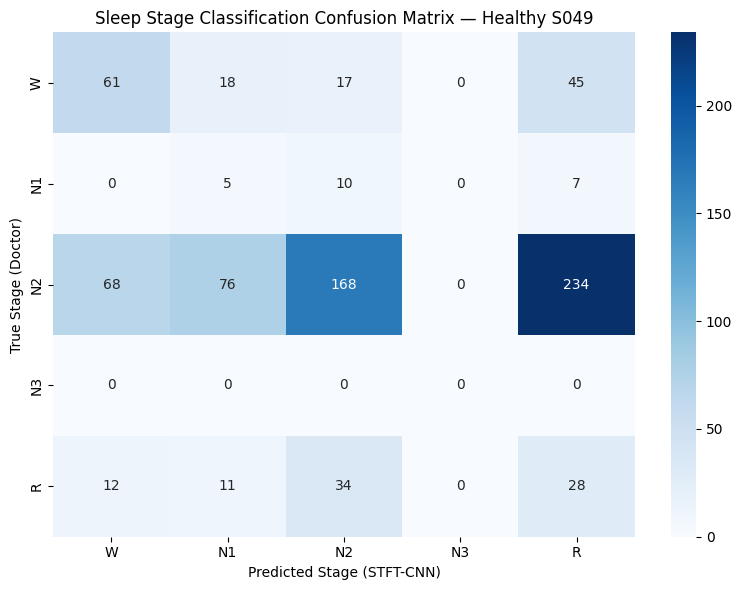

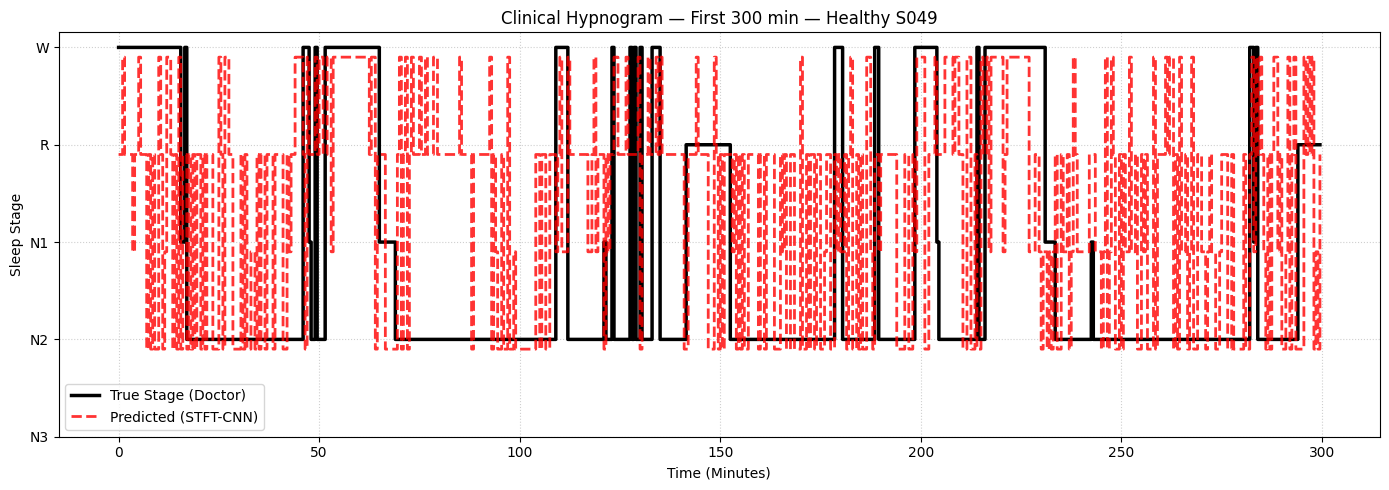

(array([4, 4, 0, 4, 4, 4, 4, 1, 4, 4, 0, 4, 4, 4, 2, 4, 2, 4, 2, 2, 0, 4,
        2, 1, 0, 0, 4, 2, 4, 2, 0, 2, 4, 4, 2, 4, 2, 4, 2, 4, 4, 2, 4, 2,
        4, 4, 4, 2, 2, 2, 0, 4, 2, 0, 0, 4, 4, 2, 2, 2, 2, 4, 2, 4, 2, 2,
        1, 1, 2, 4, 2, 4, 4, 2, 4, 4, 4, 2, 4, 4, 4, 4, 2, 2, 4, 1, 4, 4,
        0, 0, 0, 0, 4, 2, 0, 4, 4, 4, 0, 4, 0, 0, 4, 4, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 2, 4, 4, 4,
        4, 2, 2, 2, 2, 2, 2, 4, 0, 2, 4, 0, 2, 4, 0, 4, 4, 4, 0, 4, 4, 0,
        4, 4, 4, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4,
        2, 4, 4, 4, 4, 4, 4, 4, 4, 0, 2, 4, 1, 2, 2, 4, 2, 2, 0, 2, 2, 1,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 2, 4, 4, 2, 2, 4, 4, 4, 1, 4,
        0, 1, 1, 1, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1, 4, 0, 1, 4, 4, 4,
        2, 4, 1, 4, 4, 0, 0, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 0, 2, 4, 4, 4,
        0, 4, 4, 4, 0, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 4, 4,
        4, 4, 0, 4, 4, 4, 4, 4, 2, 2, 

In [25]:
print("=== Test Healthy (S049) ===")
evaluate_and_plot(model_c, loader_healthy, title_suffix=' — Healthy S049')


Test with severe patient (S046)

=== Test Severe (S046) ===
Accuracy  : 0.2136
Macro-F1  : 0.1214  ← 关键指标
              precision    recall  f1-score   support

           W       0.28      0.62      0.39       173
          N1       0.03      0.47      0.05        17
          N2       0.65      0.10      0.17       406
          N3       0.00      0.00      0.00        43
           R       0.00      0.00      0.00        82

    accuracy                           0.21       721
   macro avg       0.19      0.24      0.12       721
weighted avg       0.43      0.21      0.19       721



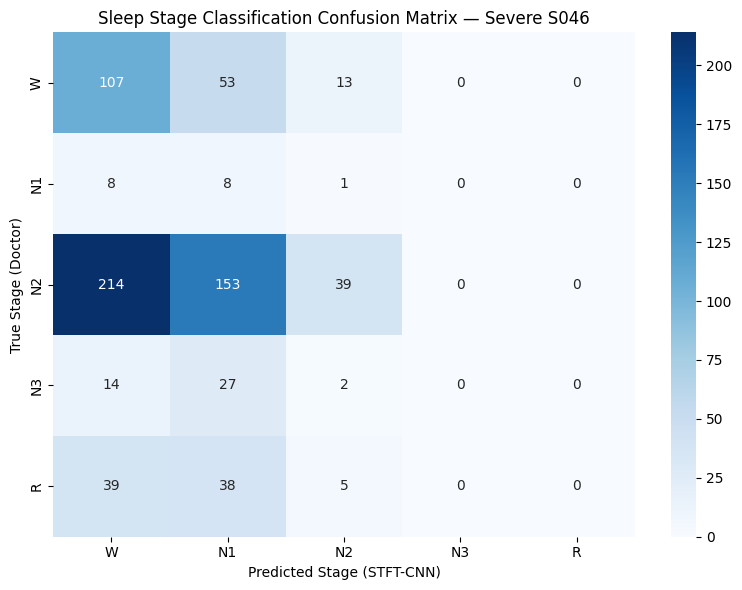

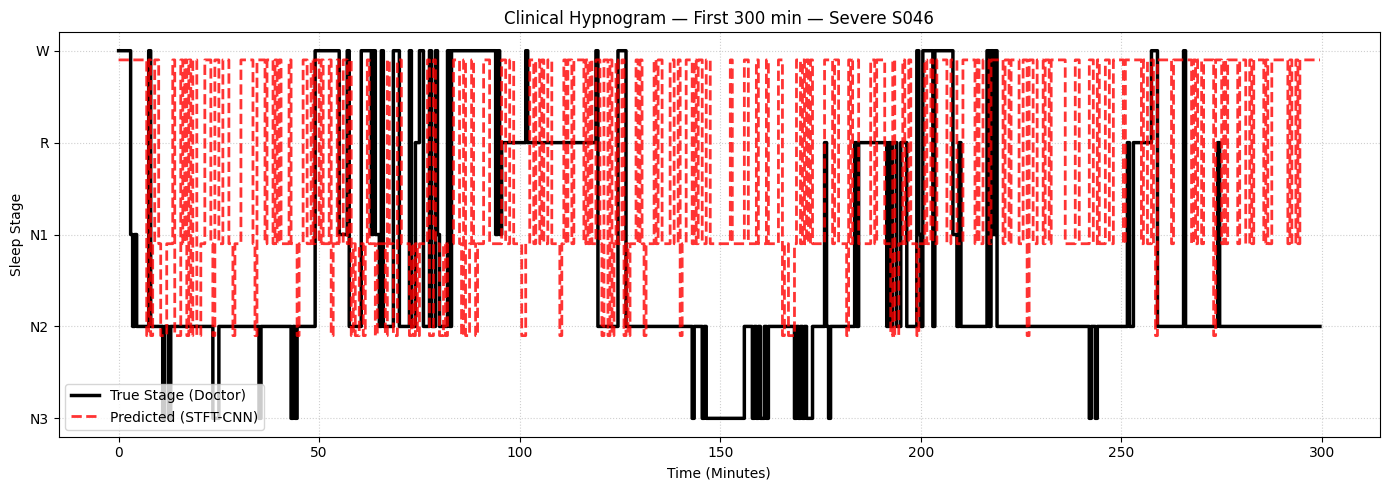

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 1, 0, 0, 1, 2,
        2, 2, 1, 1, 1, 0, 2, 2, 2, 0, 1, 0, 2, 0, 2, 0, 0, 2, 2, 1, 1, 0,
        0, 0, 1, 2, 0, 0, 1, 1, 0, 0, 0, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0, 0,
        0, 1, 2, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1,
        1, 2, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0,
        1, 1, 0, 0, 1, 0, 2, 1, 2, 2, 1, 1, 2, 1, 0, 1, 1, 1, 2, 1, 1, 1,
        1, 2, 0, 1, 1, 2, 2, 0, 0, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1,
        0, 2, 2, 0, 1, 1, 2, 2, 1, 2, 1, 1, 1, 0, 0, 0, 1, 2, 0, 2, 2, 1,
        0, 1, 2, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
        1, 1, 1, 2, 2, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
        2, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 2,
        0, 0, 2, 0, 2, 1, 0, 1, 1, 0, 2, 1, 2, 1, 1, 1, 0, 1, 0, 1, 2, 1,
        1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 2, 1, 1, 0, 0, 0,
        1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 

In [26]:
print("=== Test Severe (S046) ===")
evaluate_and_plot(model_c, loader_severe, title_suffix=' — Severe S046')


## Summary — Comparison Table
与 TimesNet 对比用的汇总表

In [27]:
results = {}
for name, loader in [('Avg S014',     loader_avg),
                     ('Healthy S049', loader_healthy),
                     ('Severe S046',  loader_severe)]:
    model_c.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            out = model_c(X_b.to(DEVICE))
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(y_b.numpy())
    preds, trues = np.array(preds), np.array(trues)
    results[name] = {
        'Accuracy':  round(accuracy_score(trues, preds), 4),
        'Macro-F1':  round(f1_score(trues, preds, average='macro', zero_division=0), 4),
    }

print("\n" + "="*50)
print(f"{'Test Set':<18} {'Accuracy':>10} {'Macro-F1':>10}")
print("-"*40)
for name, r in results.items():
    print(f"{name:<18} {r['Accuracy']:>10.4f} {r['Macro-F1']:>10.4f}")
print("="*50)
print("\n(把上面数字填入论文 Table，和 TimesNet 结果横向对比)")



Test Set             Accuracy   Macro-F1
----------------------------------------
Avg S014               0.1985     0.1387
Healthy S049           0.3300     0.2706
Severe S046            0.2136     0.1214

(把上面数字填入论文 Table，和 TimesNet 结果横向对比)


Save model

In [28]:
os.makedirs('./stft_results', exist_ok=True)
torch.save(best_state_c, './stft_results/stft_cnn_best.pt')
print("Model saved to ./stft_results/stft_cnn_best.pt")


Model saved to ./stft_results/stft_cnn_best.pt
